# GloFAS Riverine Discharge Pipeline

This notebook demonstrates the GloFAS v4.0 riverine discharge pipeline: a 51-member ensemble river discharge forecast, sparse-filtered to flood-relevant cells and stored as a compressed Zarr ZipStore.


## Overview

| Step | What happens |
|---|---|
| 1. Download | `ensemble_perturbed_forecasts` (50 members) + `control_forecast` (1) via `cdsapi`, global 60°S-60°N, 7 daily lead times (24-168h) |
| 2. Sparse filter | Keep only cells where ≥1 of 51 members, on ≥1 of 7 days, exceeds the RP2yr threshold — everything else is dropped entirely |
| 3. Build Zarr | Compressed ZipStore, `float32`, shape `(member=51, step=7, n_cells)` — **sparse**, not a dense lat/lon grid |
| 4. Stage (optional) | Upload to Snowflake internal stage and insert a `RIVER_FORECASTS` metadata row |

**Key facts about the data:**
- Values are **not accumulated** (unlike `tp`/`ro`) — each step is discharge in the preceding 24h, read directly
- Member index `i` → ECMWF member `member_numbers[i]` (1-50 = ENS perturbed, 51 = control) — same numbering convention as `TC_TRACKS.ENSEMBLE_MEMBER` and the precip/wind pipelines
- The Zarr's `data` array has **no fixed lat/lon grid index** — use the parallel `cell_lat`/`cell_lon` arrays to locate each stored value; visualizations reconstruct a dense raster from these for plotting
- Requires the official RP threshold files to already be cached (`setup_glofas_thresholds.py`, run once manually) — the sparse filter depends on them

| Output file | Snowflake table | Shape |
|---|---|---|
| `river_YYYYMMDD.zarr.zip` | `RIVER_FORECASTS` | `(51 members, 7 steps, n_cells)` — n_cells varies by date/region activity |

## Setup

In [1]:
import numpy as np
from pathlib import Path

from glofas_downloader import download_glofas_forecast
from visualization import (
    show_glofas_ensemble_mean, show_glofas_period_panels, show_glofas_exceedance,
    find_glofas_hotspot, find_glofas_active_cell, show_glofas_gauge_hydrograph,
)

In [2]:
# ── Date selection ──────────────────────────────────────────────────────────
#
# GloFAS's cache key is date-only (no run-time component) — it publishes once
# per calendar day, driven only by the 00Z IFS ENS cycle, with ~11h publication
# latency. If the requested date isn't published yet, the downloader
# automatically falls back to the previous day (logged clearly when it happens).

SELECTED_DATE = "2026-07-02"   # "YYYY-MM-DD"

# ── Threshold source ─────────────────────────────────────────────────────────
# 'local' avoids needing Snowflake credentials for this demo, requires the RP
# threshold files already cached locally (setup_glofas_thresholds.py --local-only).
# In production this defaults to 'snowflake' even when DATA_PIPELINE_DB=LOCAL,
# since thresholds are static reference files cached independently of storage mode.
THRESHOLD_SOURCE = "local"
THRESHOLD_LOCAL_DIR = "glofas_data/thresholds_cache"

# ── Visualization settings ───────────────────────────────────────────────────
GLOFAS_STEP_H = 72          # lead hour for ensemble mean / exceedance maps (24-168)
GLOFAS_RP = "2.0"           # return-period tier for the exceedance map (2.0/5.0/.../500.0)

# Output directory
GLOFAS_DIR = Path('glofas_data')
GLOFAS_DIR.mkdir(exist_ok=True)

print(f"Target: {SELECTED_DATE}")

Target: 2026-07-02


## Step 1: Download GloFAS Discharge Forecast

Downloads the ensemble (50 members) and control (1 member) forecasts, applies the sparse RP2yr filter, and builds the Zarr.

In [3]:
d = SELECTED_DATE.replace('-', '')
# Nested under a {date}/ subfolder (not flat in GLOFAS_DIR)
zarr_path = GLOFAS_DIR / d / f"river_{d}.zarr.zip"

if zarr_path.exists():
    print(f"Found existing file — skipping download.")
else:
    result = download_glofas_forecast(
        date=SELECTED_DATE,
        output_dir=str(GLOFAS_DIR),
        upload_to_stage=False,
        threshold_source=THRESHOLD_SOURCE,
        threshold_local_dir=THRESHOLD_LOCAL_DIR,
        verbose=True,
    )
    if not result['success']:
        raise RuntimeError(
            f"Download failed for {SELECTED_DATE}. GloFAS is only available for "
            "recent dates, and only once it's been published (~11h after the 00Z "
            "cycle) — try an earlier date if this keeps failing."
        )
    zarr_path = result['zip_path']

print(f"Zarr ZipStore : {zarr_path}")
print(f"File size     : {Path(zarr_path).stat().st_size / 1e6:.0f} MB")

Found existing file — skipping download.
Zarr ZipStore : glofas_data/20260702/river_20260702.zarr.zip
File size     : 304 MB


## Inspect the Zarr File

Quick sanity check: sparse shape, member numbering, and the fraction of the global grid actually kept by the RP2yr filter.

In [4]:
import zarr

store = zarr.storage.ZipStore(str(zarr_path), mode='r')
root  = zarr.open_group(store=store, mode='r')
z     = root['data']
attrs = dict(root.attrs)

print("=== Zarr metadata ===")
print(f"  Shape (sparse) : {z.shape}  (members, steps, n_cells)")
print(f"  Dtype          : {z.dtype}")
print(f"  Forecast date  : {attrs['forecast_date']}")
print(f"  Lead hours     : {attrs['leadtime_hours']}")
print(f"  member_numbers : {attrs['member_numbers']}")
print(f"  Filter         : {attrs['filter_threshold']}")
n_kept, n_total = attrs['n_cells_kept'], attrs['n_cells_total']
print(f"  Cells kept     : {n_kept:,} of {n_total:,}  ({100*n_kept/n_total:.2f}%)")
print()
print("=== Data checks ===")
arr = np.asarray(z)
print(f"  Max discharge (any member/day/cell)     : {arr.max():.0f} m3/s")
print(f"  Min discharge (any member/day/cell)     : {arr.min():.2f} m3/s")
print(f"  Would float16 have overflowed (>65504)? : {arr.max() > 65504}")
store.close()

=== Zarr metadata ===
  Shape (sparse) : (51, 7, 472930)  (members, steps, n_cells)
  Dtype          : float32
  Forecast date  : 20260702
  Lead hours     : [24, 48, 72, 96, 120, 144, 168]
  member_numbers : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51]
  Filter         : RP2.0yr
  Cells kept     : 472,930 of 17,280,000  (2.74%)

=== Data checks ===
  Max discharge (any member/day/cell)     : 117180 m3/s
  Min discharge (any member/day/cell)     : 0.00 m3/s
  Would float16 have overflowed (>65504)? : True


## Visualizations

GLOFAS — ENSEMBLE MEAN DISCHARGE
  Lead: +72h  |  Cells: 472,930 of 17,280,000 total  |  Max mean discharge: 68297 m3/s


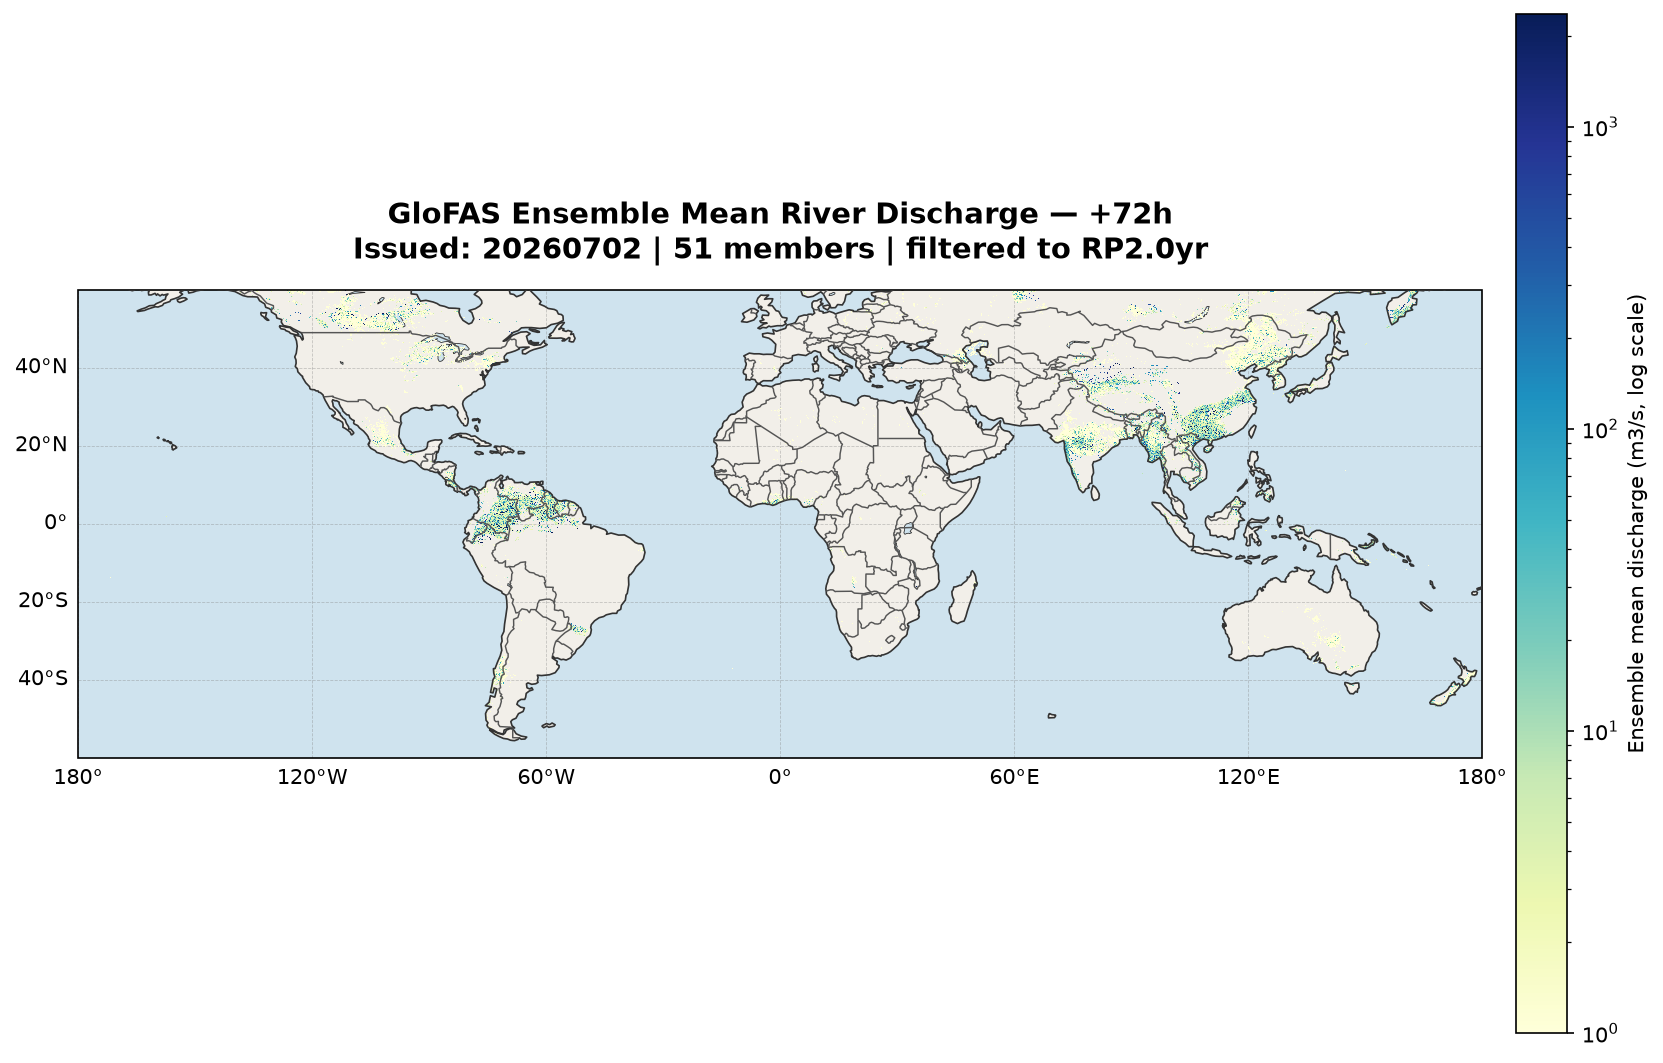

In [5]:
# Ensemble mean discharge at GLOFAS_STEP_H, global
show_glofas_ensemble_mean(zarr_path, step_h=GLOFAS_STEP_H)

GLOFAS — MULTI-DAY ENSEMBLE MAX PANELS


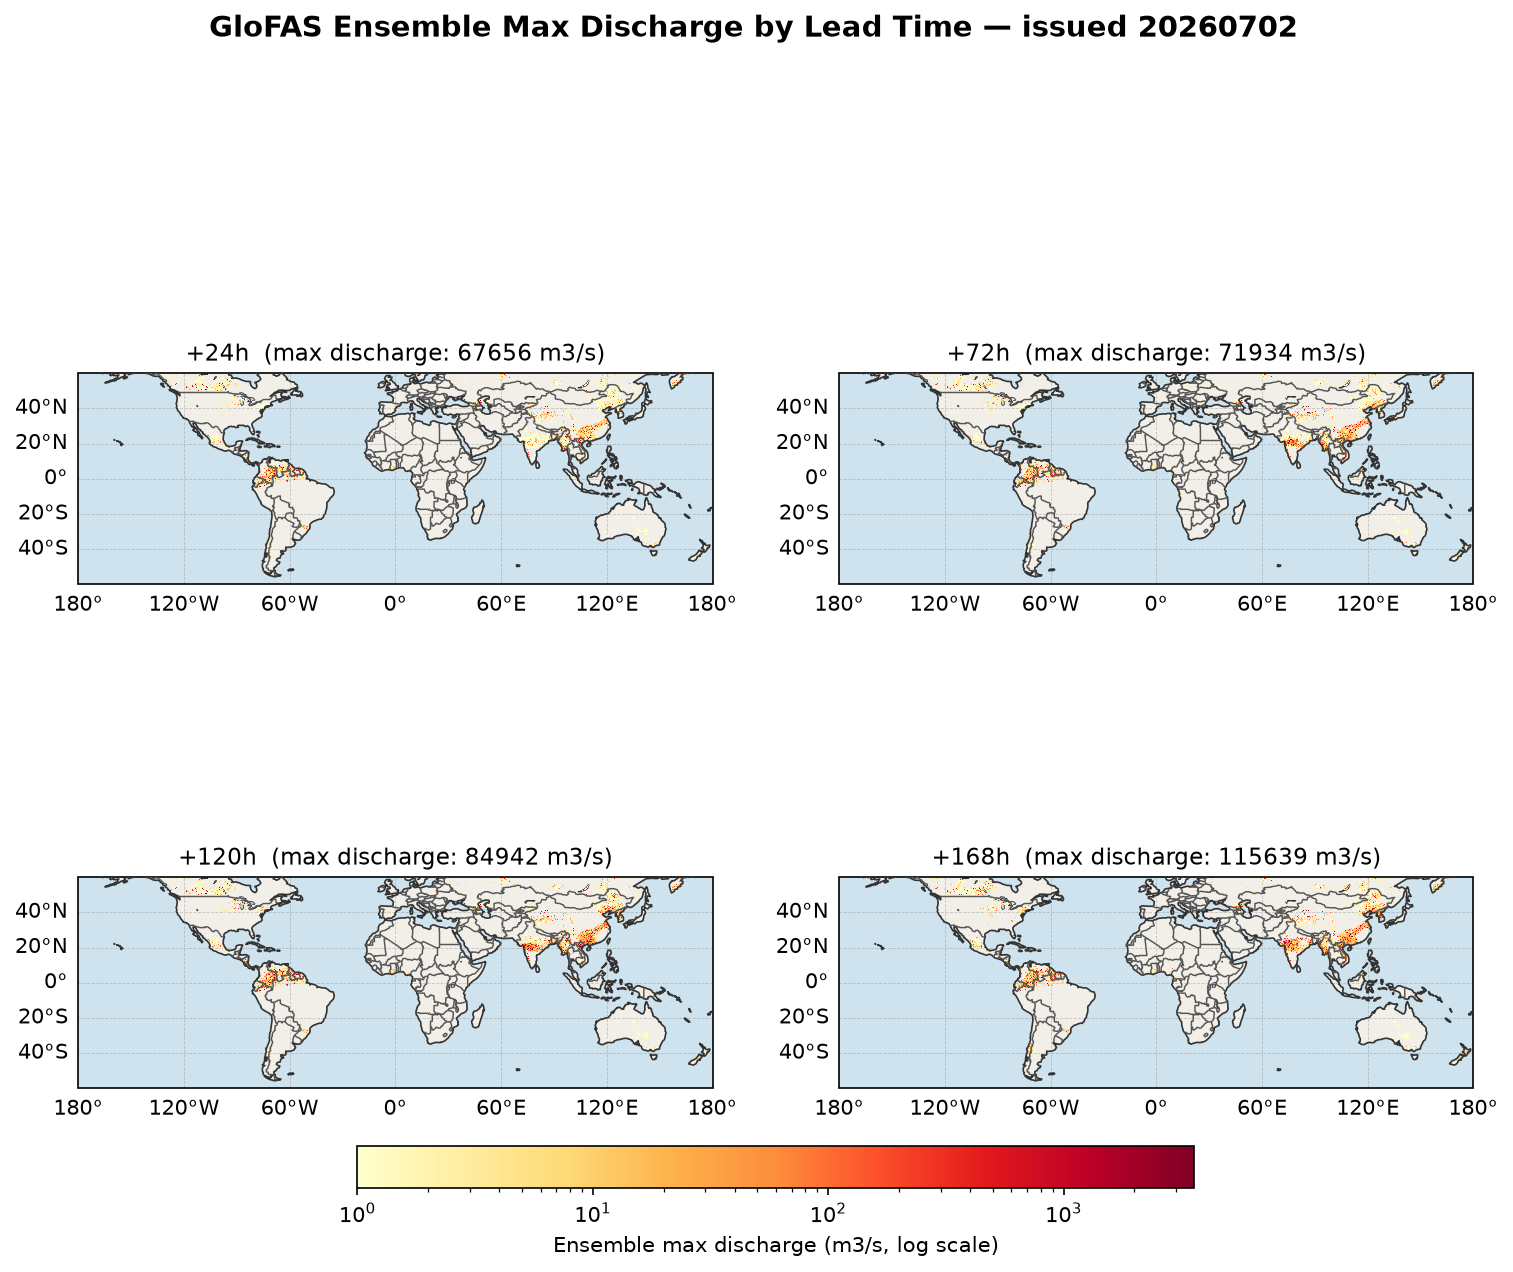

In [6]:
# Multi-day ensemble max panels
show_glofas_period_panels(zarr_path)

GLOFAS — RP2.0yr EXCEEDANCE PROBABILITY (+72h)
  Cells with any threshold data : 472,930 of 472,930
  Cells with >50% members exceeding RP2.0yr : 63,914


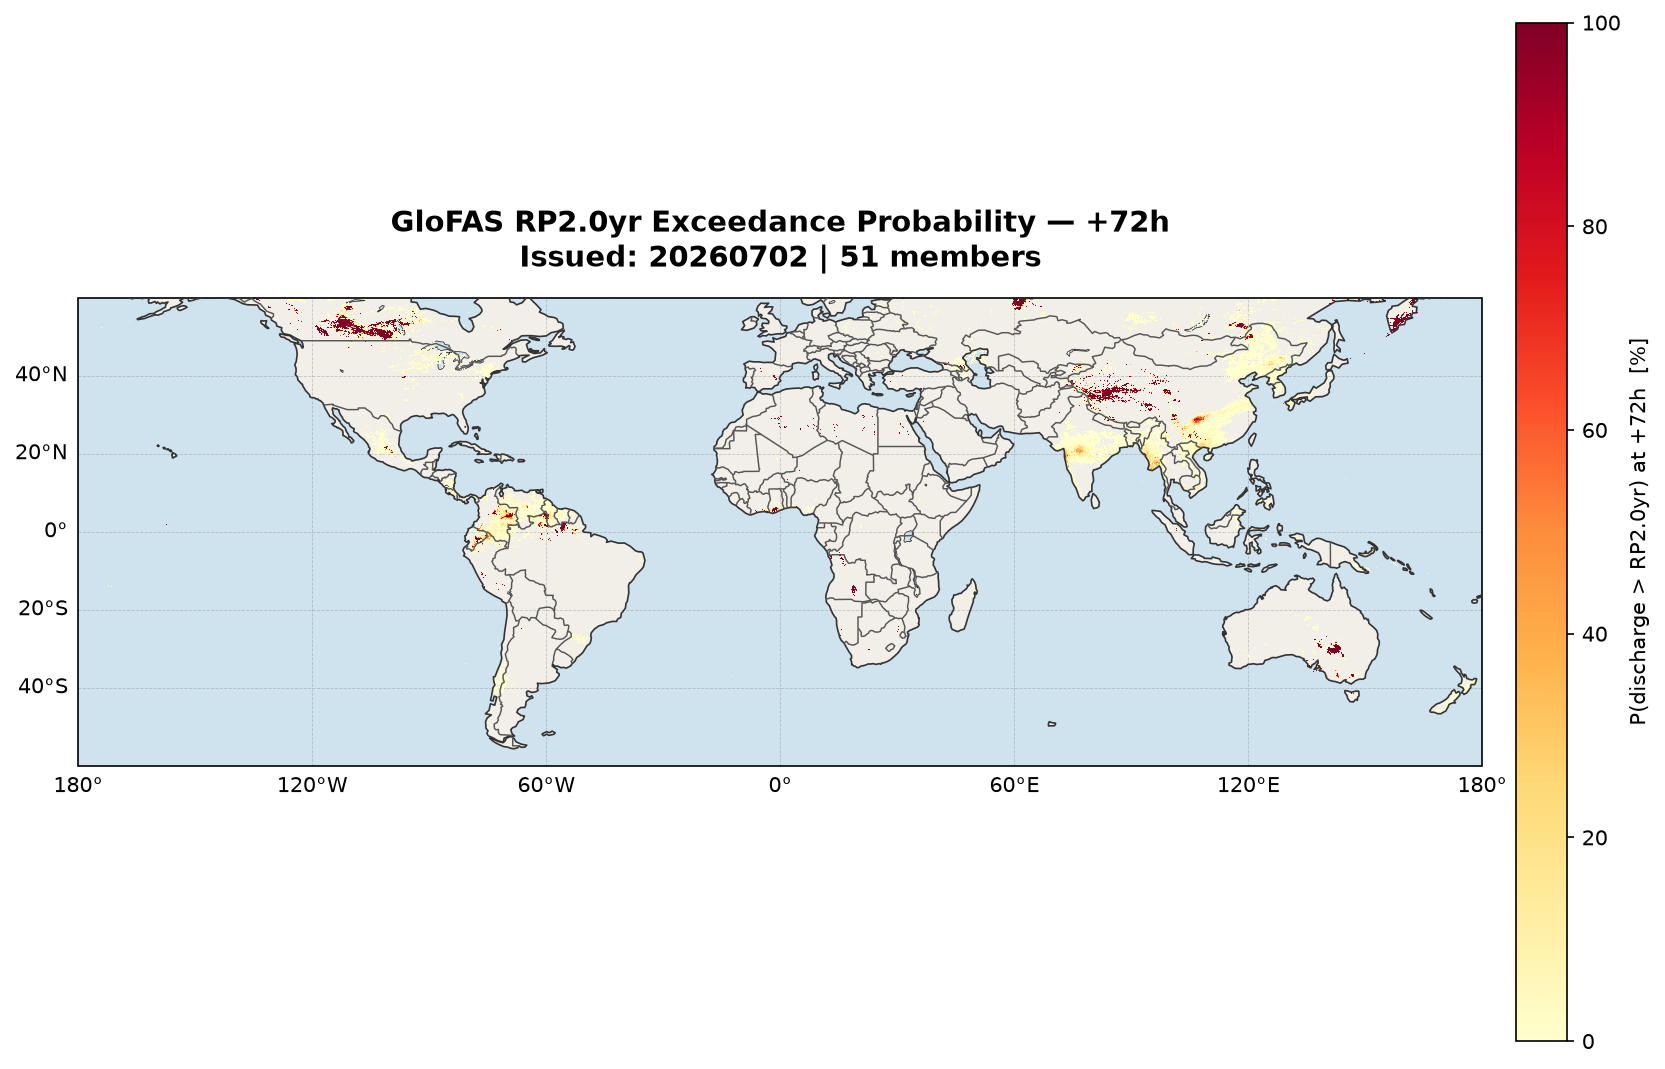

In [7]:
# Probability that discharge exceeds the official RP threshold by GLOFAS_STEP_H
# Try a higher RP (e.g. '20.0') to see a much more selective, higher-confidence map
show_glofas_exceedance(zarr_path, threshold_local_dir=THRESHOLD_LOCAL_DIR, rp=GLOFAS_RP, step_h=GLOFAS_STEP_H)

  Hotspot: 1385 cells near lat=53.9, lon=-112.0  -> bounds=(-125.0, -99.0, 41.0, 67.0)
GLOFAS — RP2.0yr EXCEEDANCE PROBABILITY (+72h)  [ZOOMED]
  Cells with any threshold data : 472,930 of 472,930
  Cells with >50% members exceeding RP2.0yr : 63,914


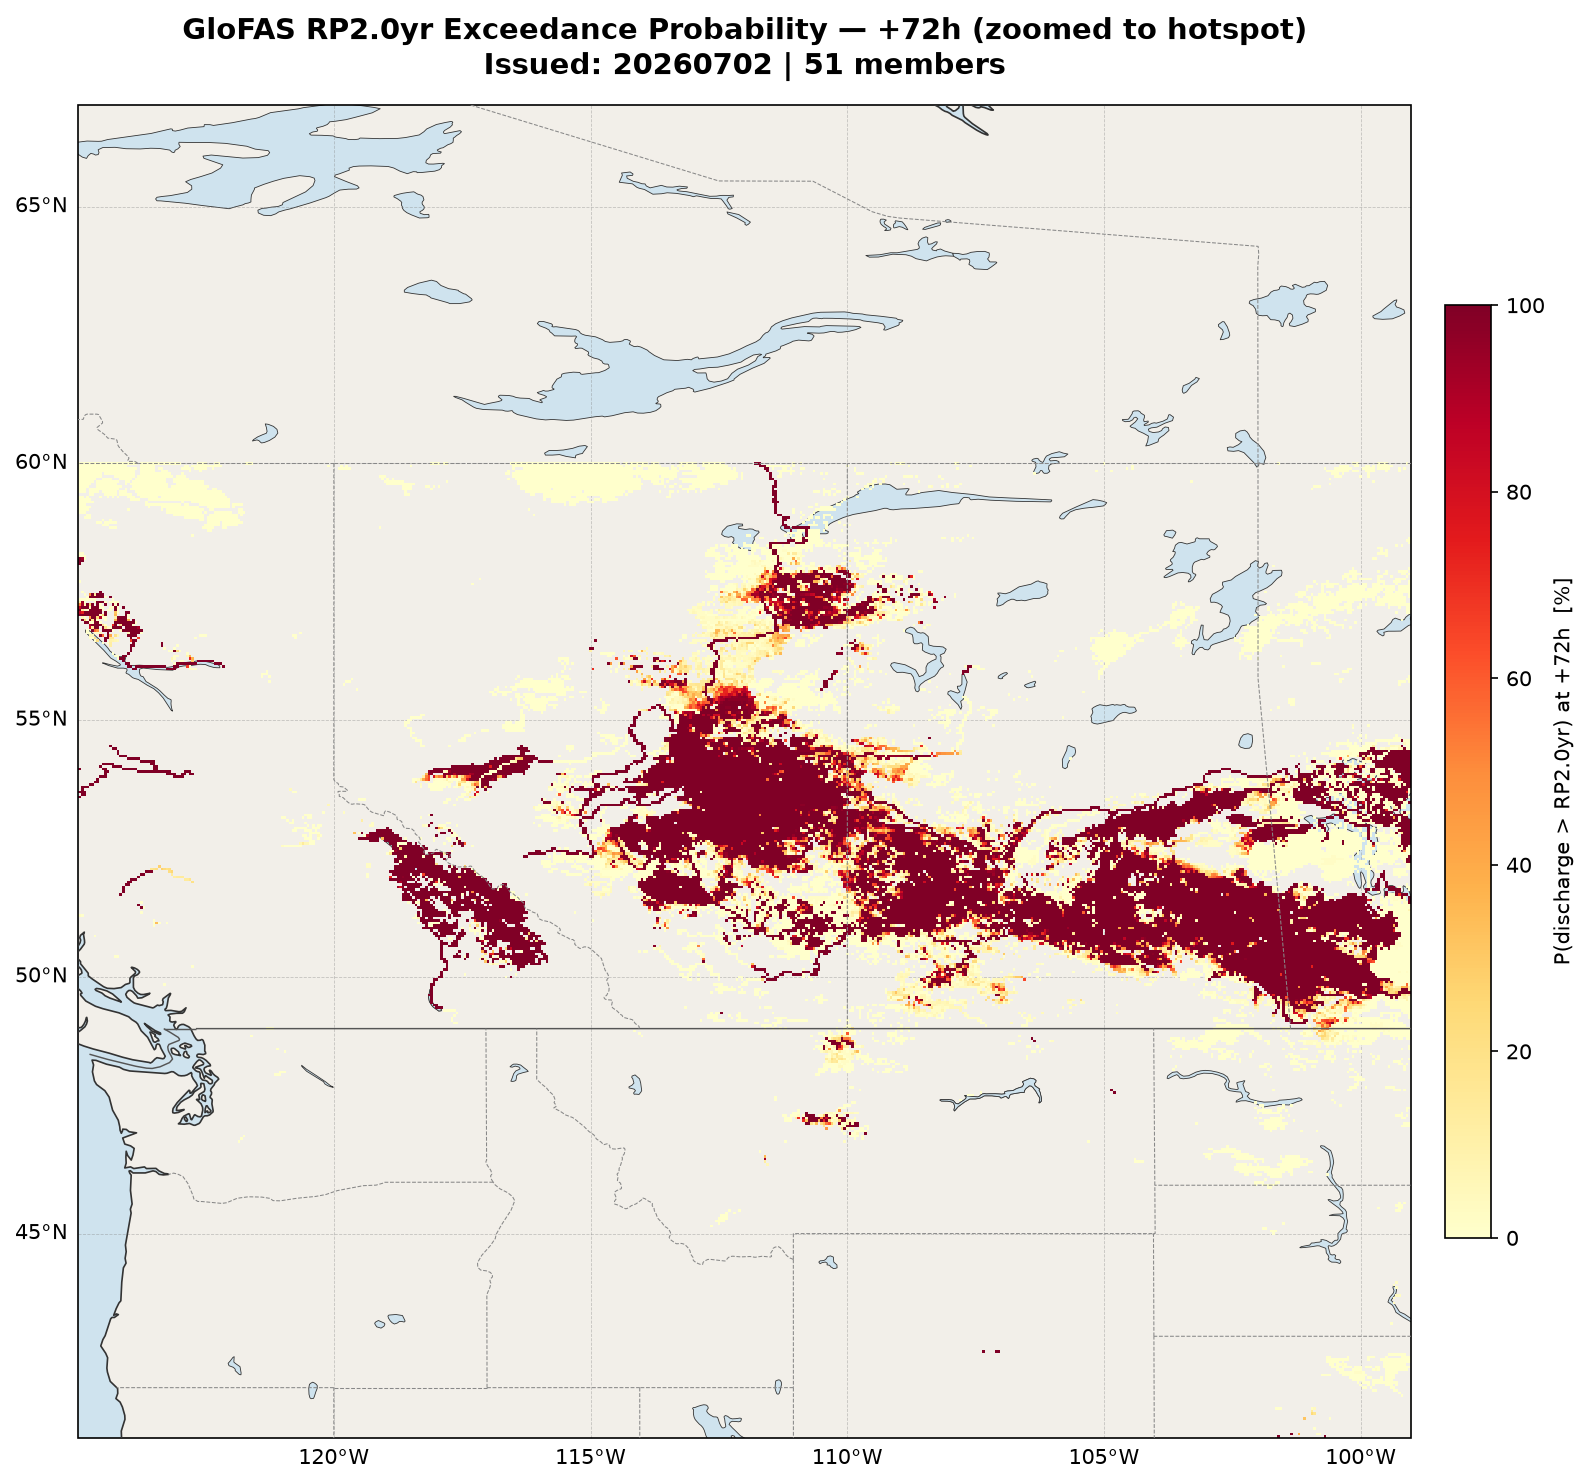

In [8]:
# Zoom into the single strongest exceedance cluster in this forecast, automatically
# located, not a hardcoded region, so this adapts to whatever the forecast actually shows.
hotspot_bounds = find_glofas_hotspot(zarr_path, threshold_local_dir=THRESHOLD_LOCAL_DIR,
                                     rp=GLOFAS_RP, step_h=GLOFAS_STEP_H)
if hotspot_bounds:
    show_glofas_exceedance(zarr_path, threshold_local_dir=THRESHOLD_LOCAL_DIR,
                          rp=GLOFAS_RP, step_h=GLOFAS_STEP_H, bounds=hotspot_bounds)

  Hotspot: 764 cells near lat=53.7, lon=-111.9  -> bounds=(-125.0, -99.0, 41.0, 66.5)
GLOFAS — RP20.0yr EXCEEDANCE PROBABILITY (+72h)  [ZOOMED]
  Cells with any threshold data : 472,930 of 472,930
  Cells with >50% members exceeding RP20.0yr : 6,140


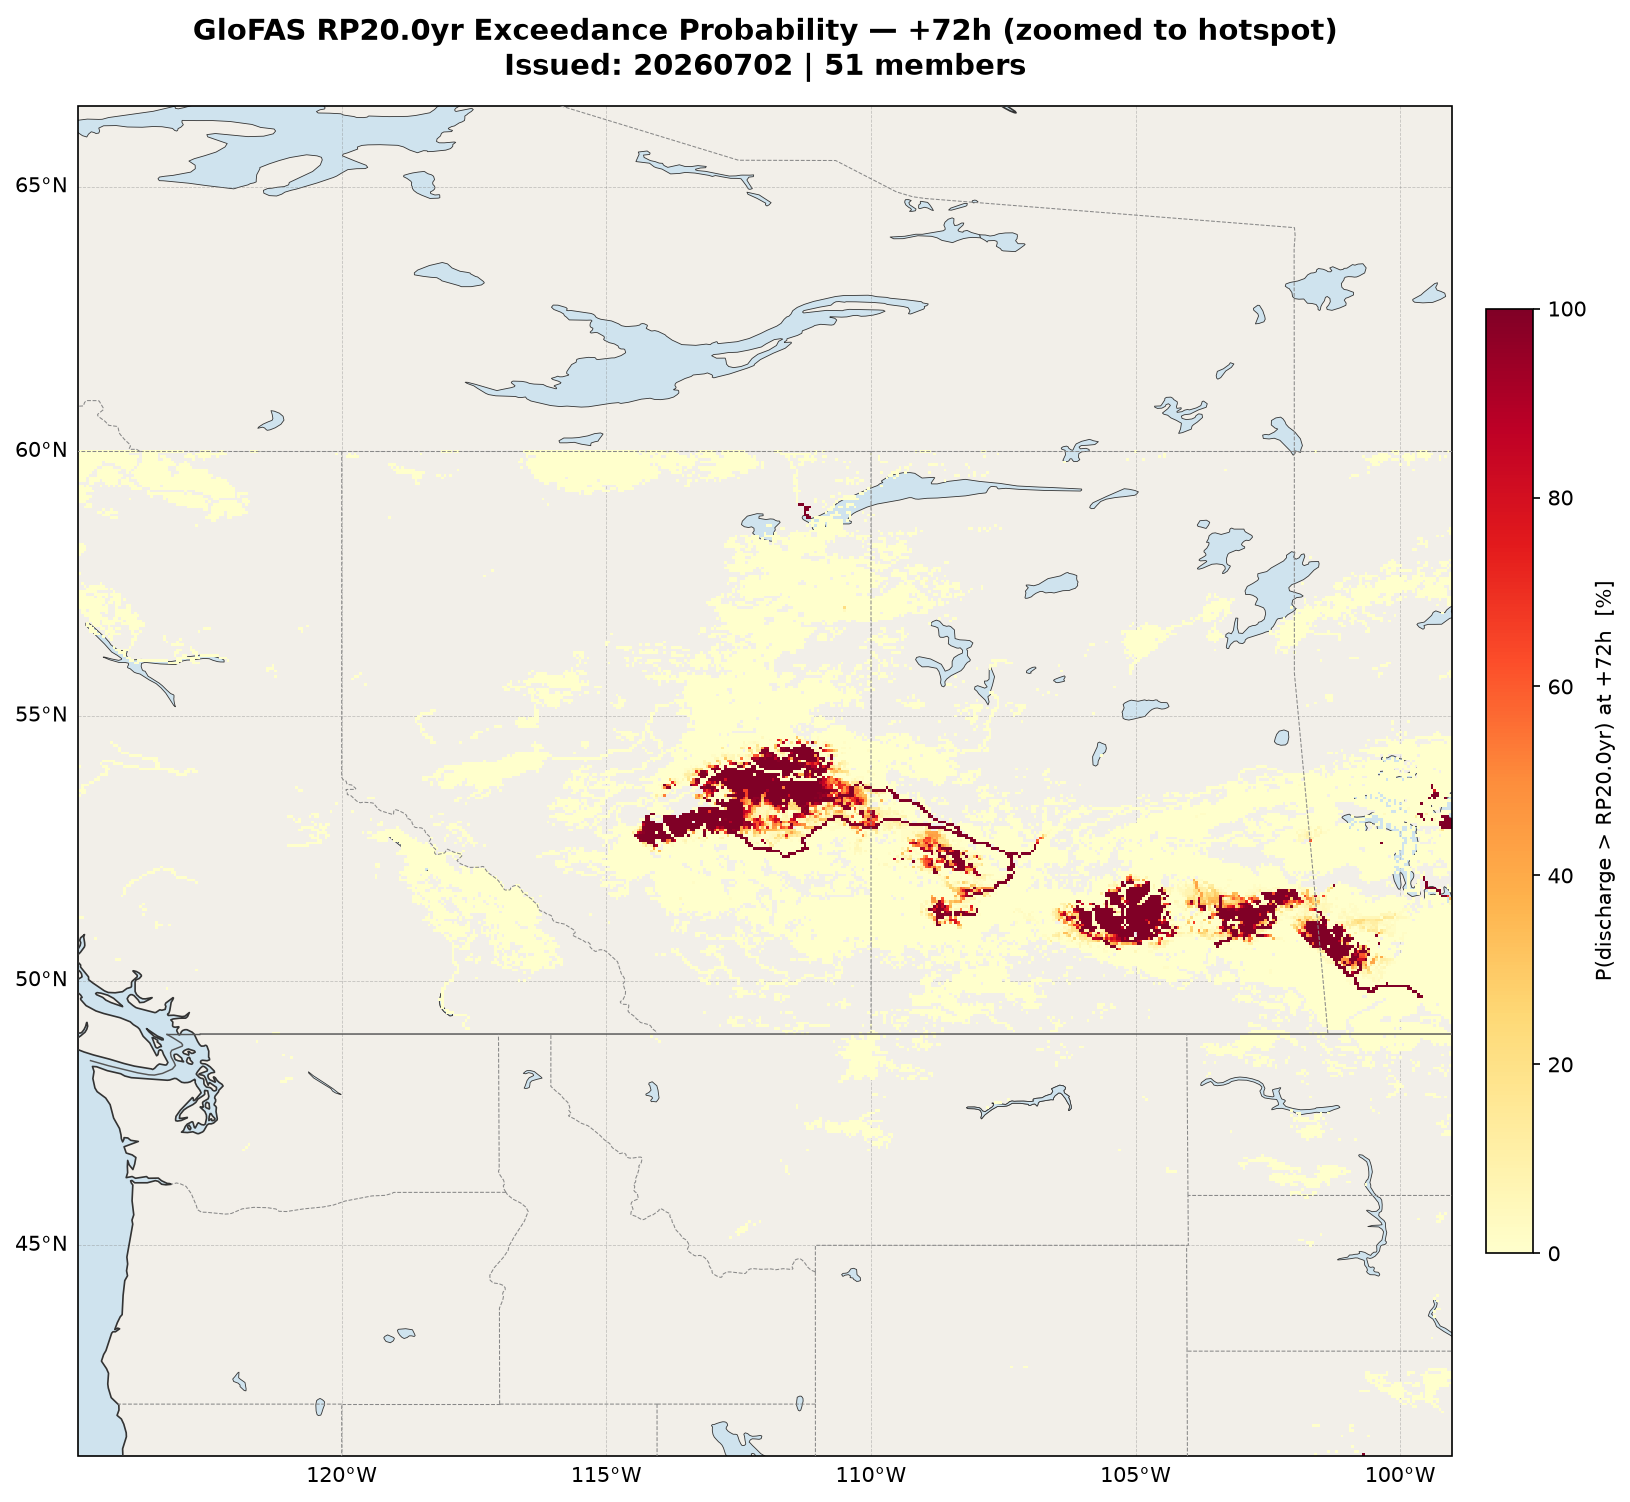

In [9]:
HIGHER_RP = "20.0"   # try 5.0 / 20.0 / 50.0 / 100.0

higher_rp_bounds = find_glofas_hotspot(zarr_path, threshold_local_dir=THRESHOLD_LOCAL_DIR,
                                       rp=HIGHER_RP, step_h=GLOFAS_STEP_H)
if higher_rp_bounds:
    show_glofas_exceedance(zarr_path, threshold_local_dir=THRESHOLD_LOCAL_DIR,
                          rp=HIGHER_RP, step_h=GLOFAS_STEP_H, bounds=higher_rp_bounds)
else:
    print(f"No cells exceed RP{HIGHER_RP}yr anywhere in this forecast — "
          "try a lower tier (e.g. '5.0') or a different SELECTED_DATE.")

  Most active cell: lat=22.18, lon=113.43  (max discharge rises 35605 -> 115639 m3/s over the horizon)
GLOFAS — GAUGE HYDROGRAPH
  Cell: lat=22.18, lon=113.43
  Peak across all members/days: 115639 m3/s
  Thresholds found: RP2.0yr=48171, RP5.0yr=59033, RP20.0yr=73123


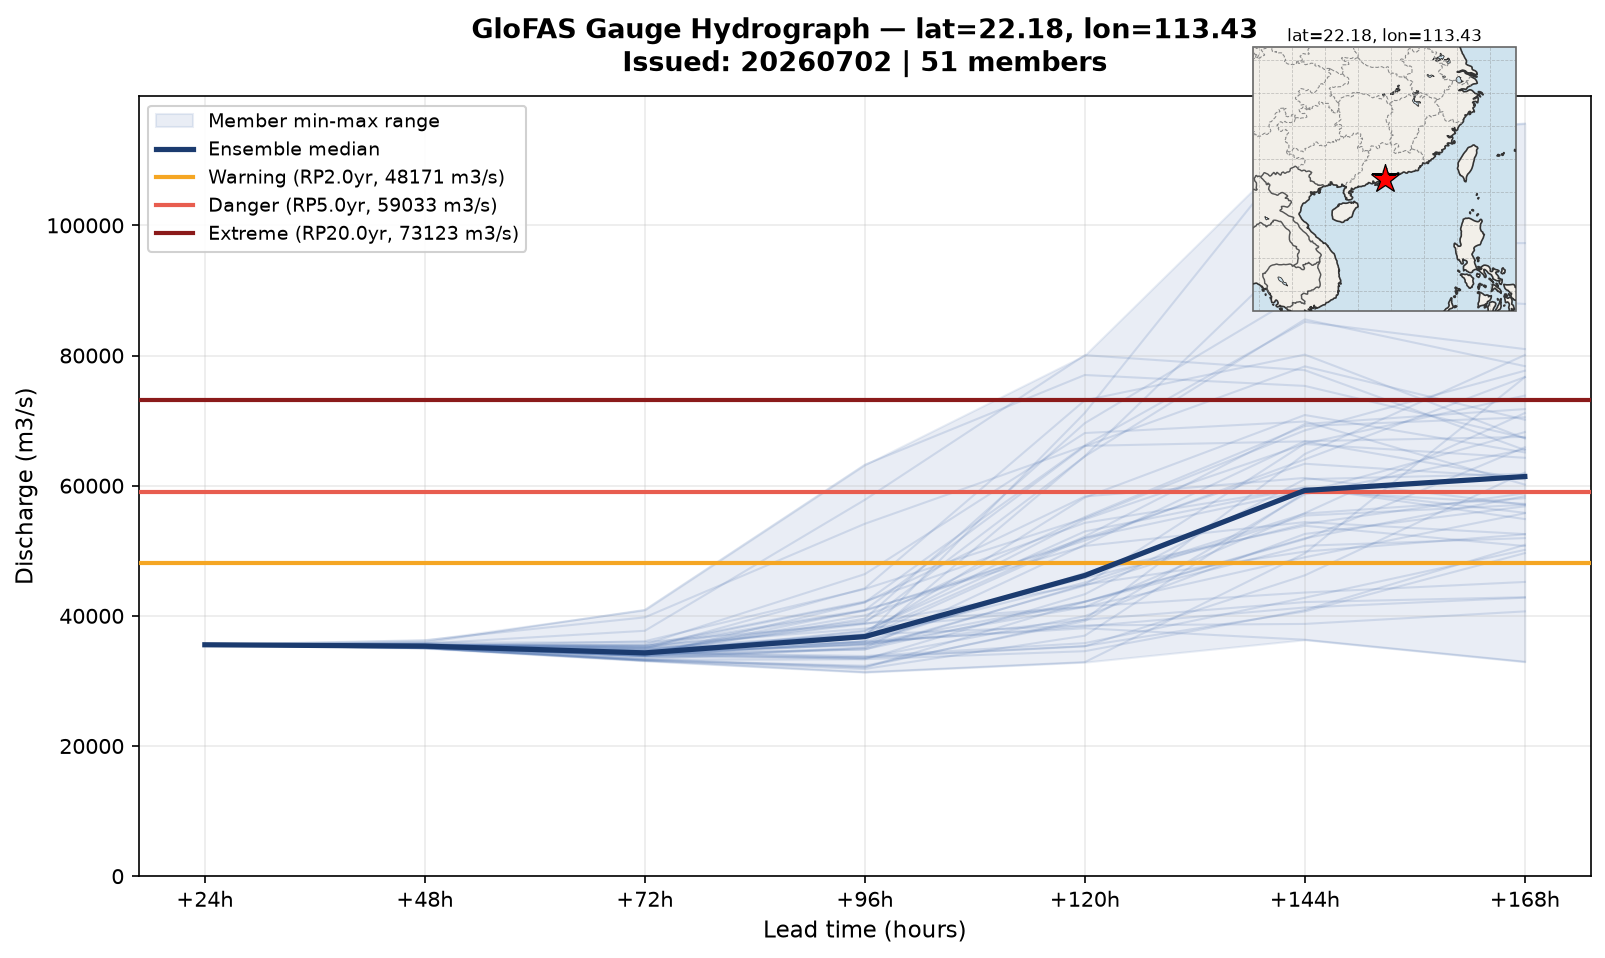

In [10]:
# Single-gauge hydrograph: all 51 member traces + RP threshold lines, at the
# cell with the most dramatic developing signal in this forecast (auto-selected,
# not hardcoded, pass cell_lat/cell_lon explicitly to pick own location instead)
active_lat, active_lon = find_glofas_active_cell(zarr_path)
show_glofas_gauge_hydrograph(zarr_path, cell_lat=active_lat, cell_lon=active_lon,
                             threshold_local_dir=THRESHOLD_LOCAL_DIR)

## GloFAS x JRC Flood-Extent Masking

The visualizations above all work with raw discharge-exceedance probability, applied uniformly across each GloFAS 0.05° (~5km) cell. That overstates exposure: a GloFAS cell is a channel/discharge property, not a locally-uniform hazard the way a rain cell is — the real channel/floodplain is typically much narrower than the whole 5km cell.

**The fix**: combine GloFAS's per-cycle discharge-exceedance with [JRC's Global River Flood Hazard Maps v2.1](https://data.jrc.ec.europa.eu/), a static, pre-computed flood-extent raster per return period, built on the same LISFLOOD/LISFLOOD-FP model family GloFAS's own discharge forecast uses.

| Step | What happens |
|---|---|
| 1. Cache (one-time, separate) | `setup_jrc_extents.py` fetches JRC's RP10/RP20/RP50/RP100 depth bands + `permanent_water_class` directly from JRC's own file server and streams each tile into a cached GeoTIFF, confined entirely to that one script, never run by the recurring pipeline |
| 2. Per-tier, per-member exceedance | For each of the 6 RP tiers (`glofas_downloader.EXTENT_RP_LEVELS`), which specific ensemble members exceed that tier's threshold, per cell per lead step, kept per-member, not collapsed into one blended probability |
| 3. Combine | For each RP tier, each JRC pixel within a GloFAS cell's footprint inherits that cell's own per-member exceedance, gated by `(JRC depth > 0.1m) x (1 - permanent_water)` |
| 4. Output | **One Parquet file per RP tier per date**: a sparse table, one row per `(pixel_lat, pixel_lon, member, step_h)` combination that's actually flooded for that member |

**Full 6-tier severity ladder**: RP2/RP5 have no native JRC map (JRC only covers RP10 and up),  they reuse RP10's own extent as a labeled upper-bound stand-in. RP10/RP20/RP50/RP100 are exact native tier matches.

In [11]:
# ── JRC cache ─────────────────────────────────────────────────────────────
# just for a small demo version
JRC_LOCAL_DIR = "glofas_data/jrc_extent_cache_demo"

jrc_dir = Path(JRC_LOCAL_DIR)
required = ["jrc_rp10.tif", "jrc_rp20.tif", "jrc_rp50.tif", "jrc_rp100.tif", "jrc_permanent_water.tif"]
missing = [f for f in required if not (jrc_dir / f).exists()]
if missing:
    print(f"Missing from {JRC_LOCAL_DIR}: {missing}")
    print(f"Run: python3 setup_jrc_extents.py --local-only {JRC_LOCAL_DIR} --bbox <west> <south> <east> <north>")
else:
    print(f"JRC cache found in {JRC_LOCAL_DIR}: {required}")
    is_demo = (jrc_dir / "README_DEMO_ONLY.txt").exists()
    if is_demo:
        print("NOTE: this is the Bangladesh-only DEMO cache")

JRC cache found in glofas_data/jrc_extent_cache_demo: ['jrc_rp10.tif', 'jrc_rp20.tif', 'jrc_rp50.tif', 'jrc_rp100.tif', 'jrc_permanent_water.tif']
NOTE: this is the Bangladesh-only DEMO cache


### Naive whole-cell vs. extent-masked, side by side

Left: raw discharge-exceedance probability painted across the whole 5km GloFAS cell (the same quantity `show_glofas_exceedance` above shows). Right: the same probability, masked down to JRC's real flood-extent footprint within each cell. `BGD_BOUNDS` matches the demo JRC cache's own coverage.

GLOFAS x JRC — EXTENT-MASKED RP10.0yr (+168h)
  2517 of 472,930 candidate cells fall within the cached JRC coverage (glofas_data/jrc_extent_cache_demo) — restricting to those before combining
  Extent-masked: 1034 GloFAS cells, 291,751 combined pixels (using JRC RP10.0 extent + permanent-water mask)
  Naive whole-cell footprint: 685 pixels at 0.05deg native resolution (not directly comparable pixel-for-pixel to the 191,854 JRC-resolution pixels above -- different grids -- but illustrates the same 'whole cell vs. real extent' gap the README's 84x/2x overstatement numbers quantify precisely)


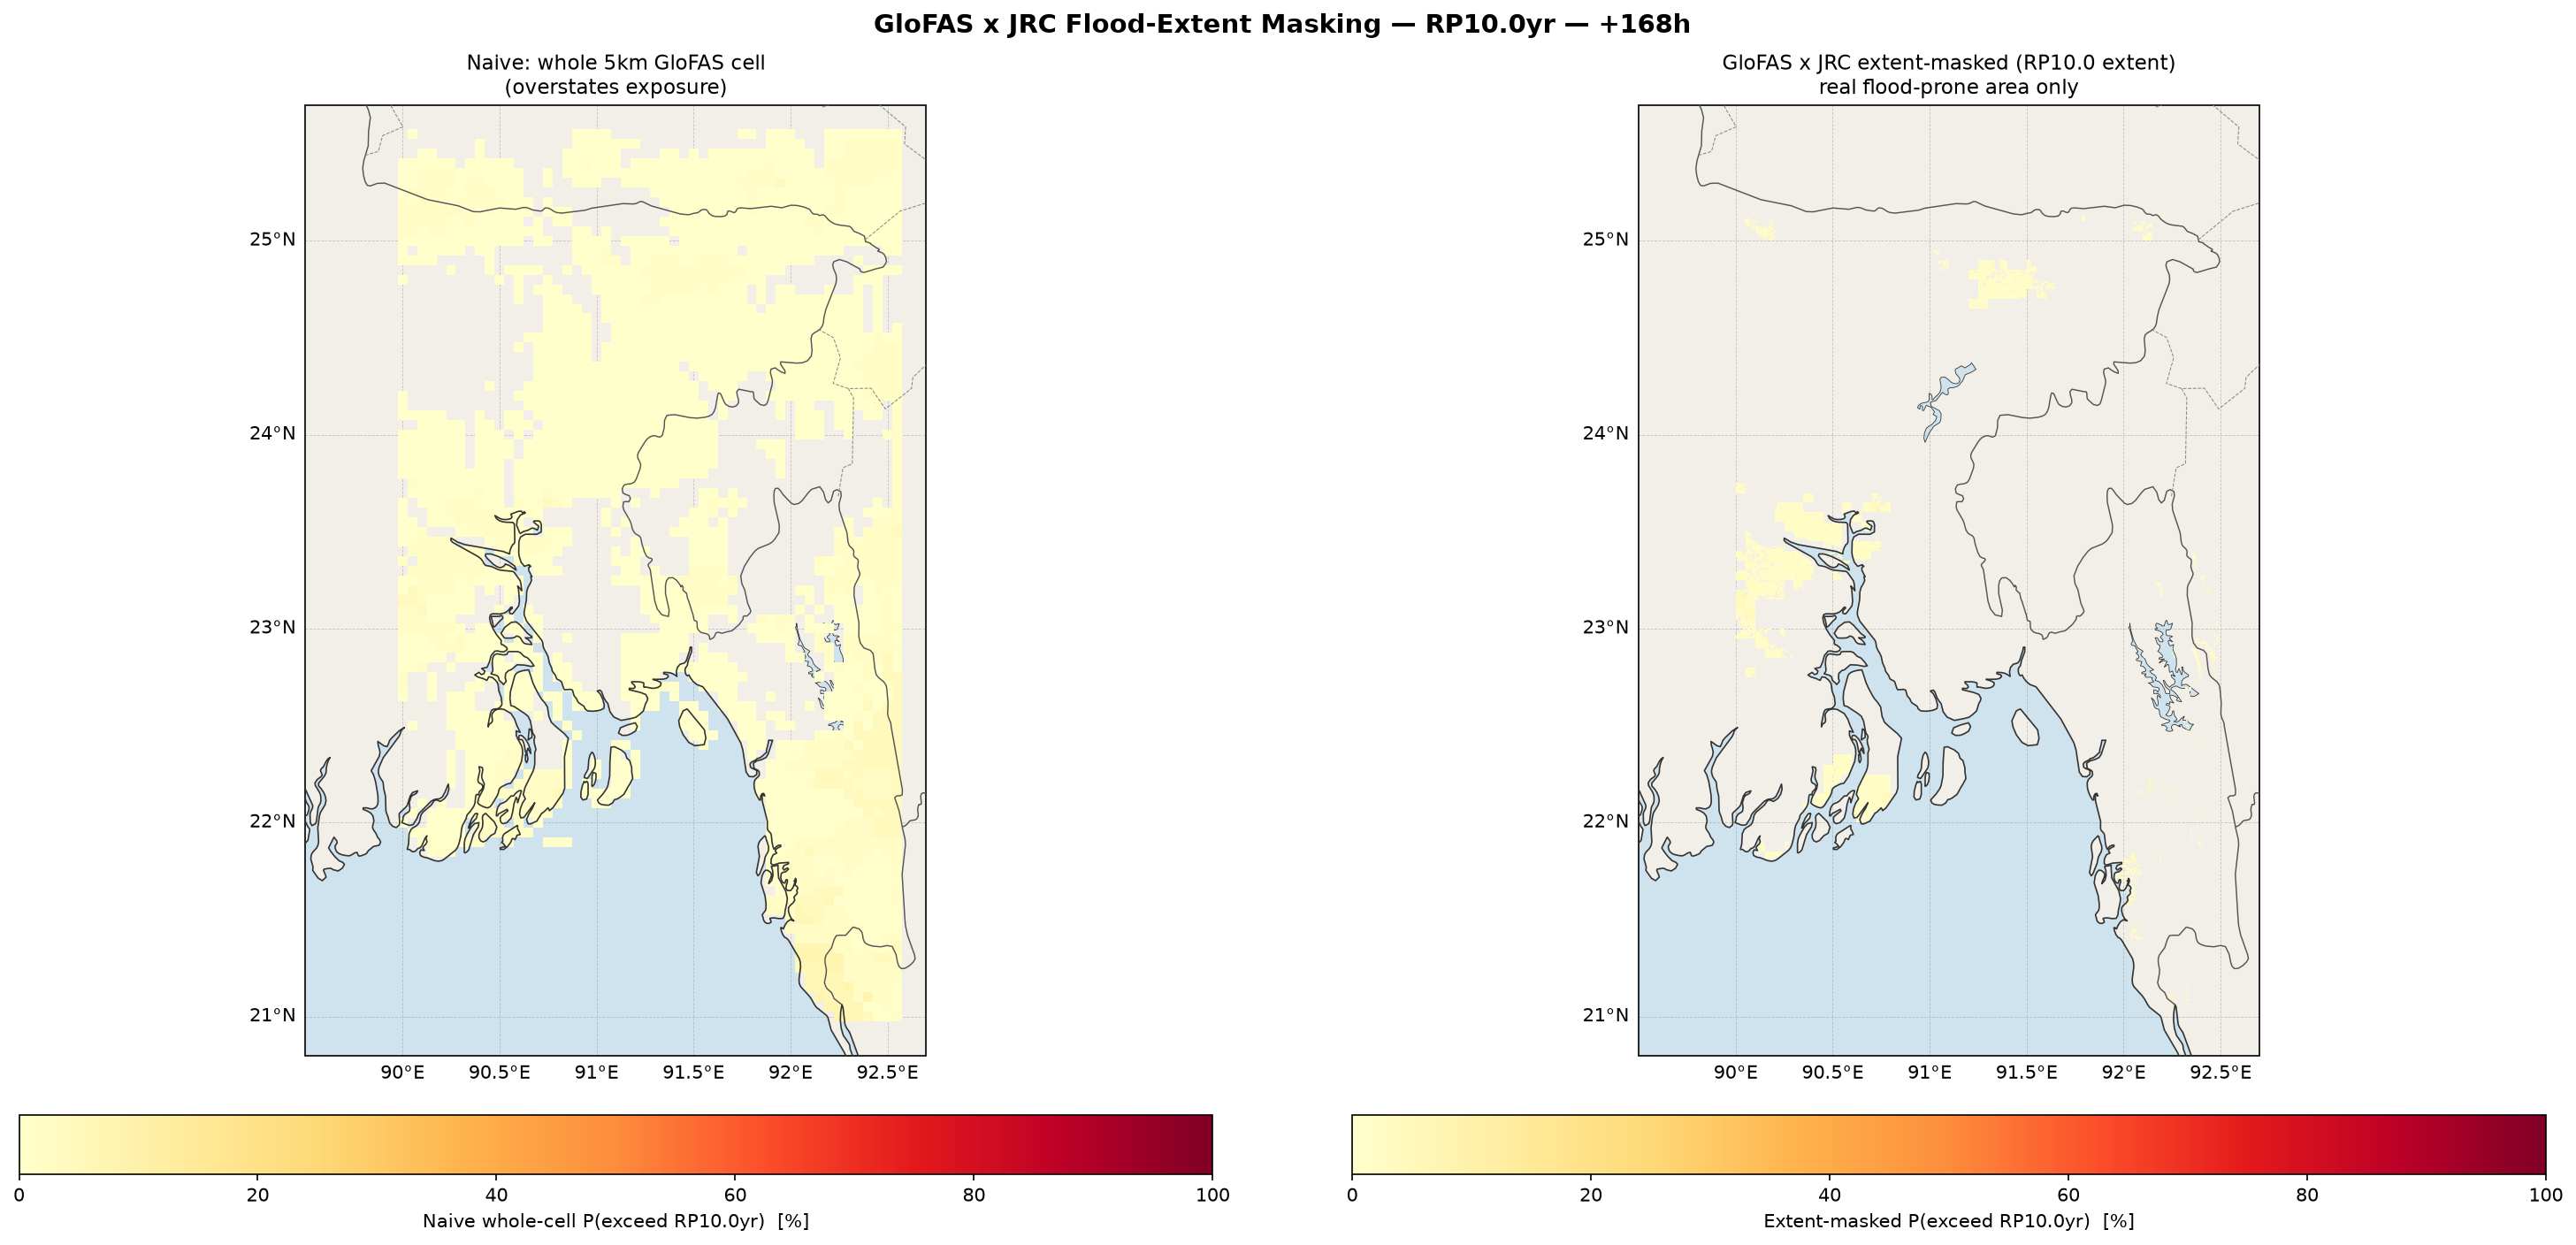

In [12]:
from visualization import show_glofas_extent_mask

# lon_min, lon_max, lat_min, lat_max, matches the demo JRC cache's own coverage
BGD_BOUNDS = (89.5, 92.7, 20.8, 25.7)

EXTENT_RP = "10.0"   # RP10 is the loosest tier JRC has a real map

EXTENT_STEP_H = 168

show_glofas_extent_mask(zarr_path, jrc_local_dir=JRC_LOCAL_DIR, rp=EXTENT_RP,
                        step_h=EXTENT_STEP_H, bounds=BGD_BOUNDS)

### Per-member flood extent

This is what `run_glofas_extent_masking()` really writes to the Snowflake stage: one Parquet file per RP tier, one row per `(pixel, member, step)` that's flooded for that specific member. The cell below first ranks all 51 members by how many pixels they flood at this RP tier and lead time (using the exact same production functions, run once for ranking), then plots the 3 members with the most flooding side by side.

In [13]:
import pandas as pd
import zarr as _zarr
import rasterio as _rasterio
from glofas_extent_masking import (
    compute_tier_member_exceedance, resolve_jrc_cache, combine_tier_per_member_parquet, EXTENT_SOURCE_TIER,
)

# Rank all 51 members by flooded-pixel count at EXTENT_RP/EXTENT_STEP_H 
_store = _zarr.storage.ZipStore(str(zarr_path), mode='r')
_root = _zarr.open_group(store=_store, mode='r')
_cell_lat_all = _root['cell_lat'][:]
_cell_lon_all = _root['cell_lon'][:]
_data_all = _root['data'][:]
_member_numbers = np.asarray(_root.attrs['member_numbers'])
_leadtime_hours = list(_root.attrs['leadtime_hours'])
_store.close()

_jrc_paths = resolve_jrc_cache('local', JRC_LOCAL_DIR)
_source_tier = EXTENT_SOURCE_TIER[EXTENT_RP]
with _rasterio.open(_jrc_paths[_source_tier]) as _src:
    _jb = _src.bounds
_pad = 0.05
_in_jrc = ((_cell_lat_all >= _jb.bottom - _pad) & (_cell_lat_all <= _jb.top + _pad) &
           (_cell_lon_all >= _jb.left - _pad) & (_cell_lon_all <= _jb.right + _pad))
_cell_lat = _cell_lat_all[_in_jrc]
_cell_lon = _cell_lon_all[_in_jrc]
_data = _data_all[:, :, _in_jrc]

_exceed_by_tier = compute_tier_member_exceedance(
    _cell_lat, _cell_lon, _data, threshold_source='local', threshold_local_dir=THRESHOLD_LOCAL_DIR,
)
_keep_mask = _exceed_by_tier[EXTENT_RP].any(axis=(0, 1))

_rank_path = Path("visualizations") / "_demo_member_ranking.parquet"
_rank_path.parent.mkdir(exist_ok=True)
combine_tier_per_member_parquet(EXTENT_RP, _cell_lat, _cell_lon, _exceed_by_tier, _keep_mask,
                                _jrc_paths, _leadtime_hours, _member_numbers, _rank_path)

_ranked = (pd.read_parquet(_rank_path)
           .query("step_h == @EXTENT_STEP_H")
           .groupby("member").size()
           .sort_values(ascending=False))
print(f"Members ranked by flooded pixel count at RP{EXTENT_RP}yr/{EXTENT_STEP_H}h (top 10 of {len(_ranked)}):")
print(_ranked.head(10))

MEMBERS_TO_COMPARE = tuple(int(m) for m in _ranked.head(3).index)
print(f"\nSelected (most flooding): {MEMBERS_TO_COMPARE}")

Members ranked by flooded pixel count at RP10.0yr/168h (top 10 of 16):
member
18    121028
12     32011
4      18164
26      7464
11      5345
10      4757
33      4463
17      2981
5       1745
23      1694
dtype: int64

Selected (most flooding): (18, 12, 4)


GLOFAS x JRC — PER-MEMBER FLOOD EXTENT RP10.0yr (+168h)
  2517 of 472,930 candidate cells fall within the cached JRC coverage (glofas_data/jrc_extent_cache_demo) — restricting to those before combining
  Per-member extent: 1034 GloFAS cells, 539,448 flooded pixel/member/step rows (using JRC RP10.0 extent + permanent-water mask)


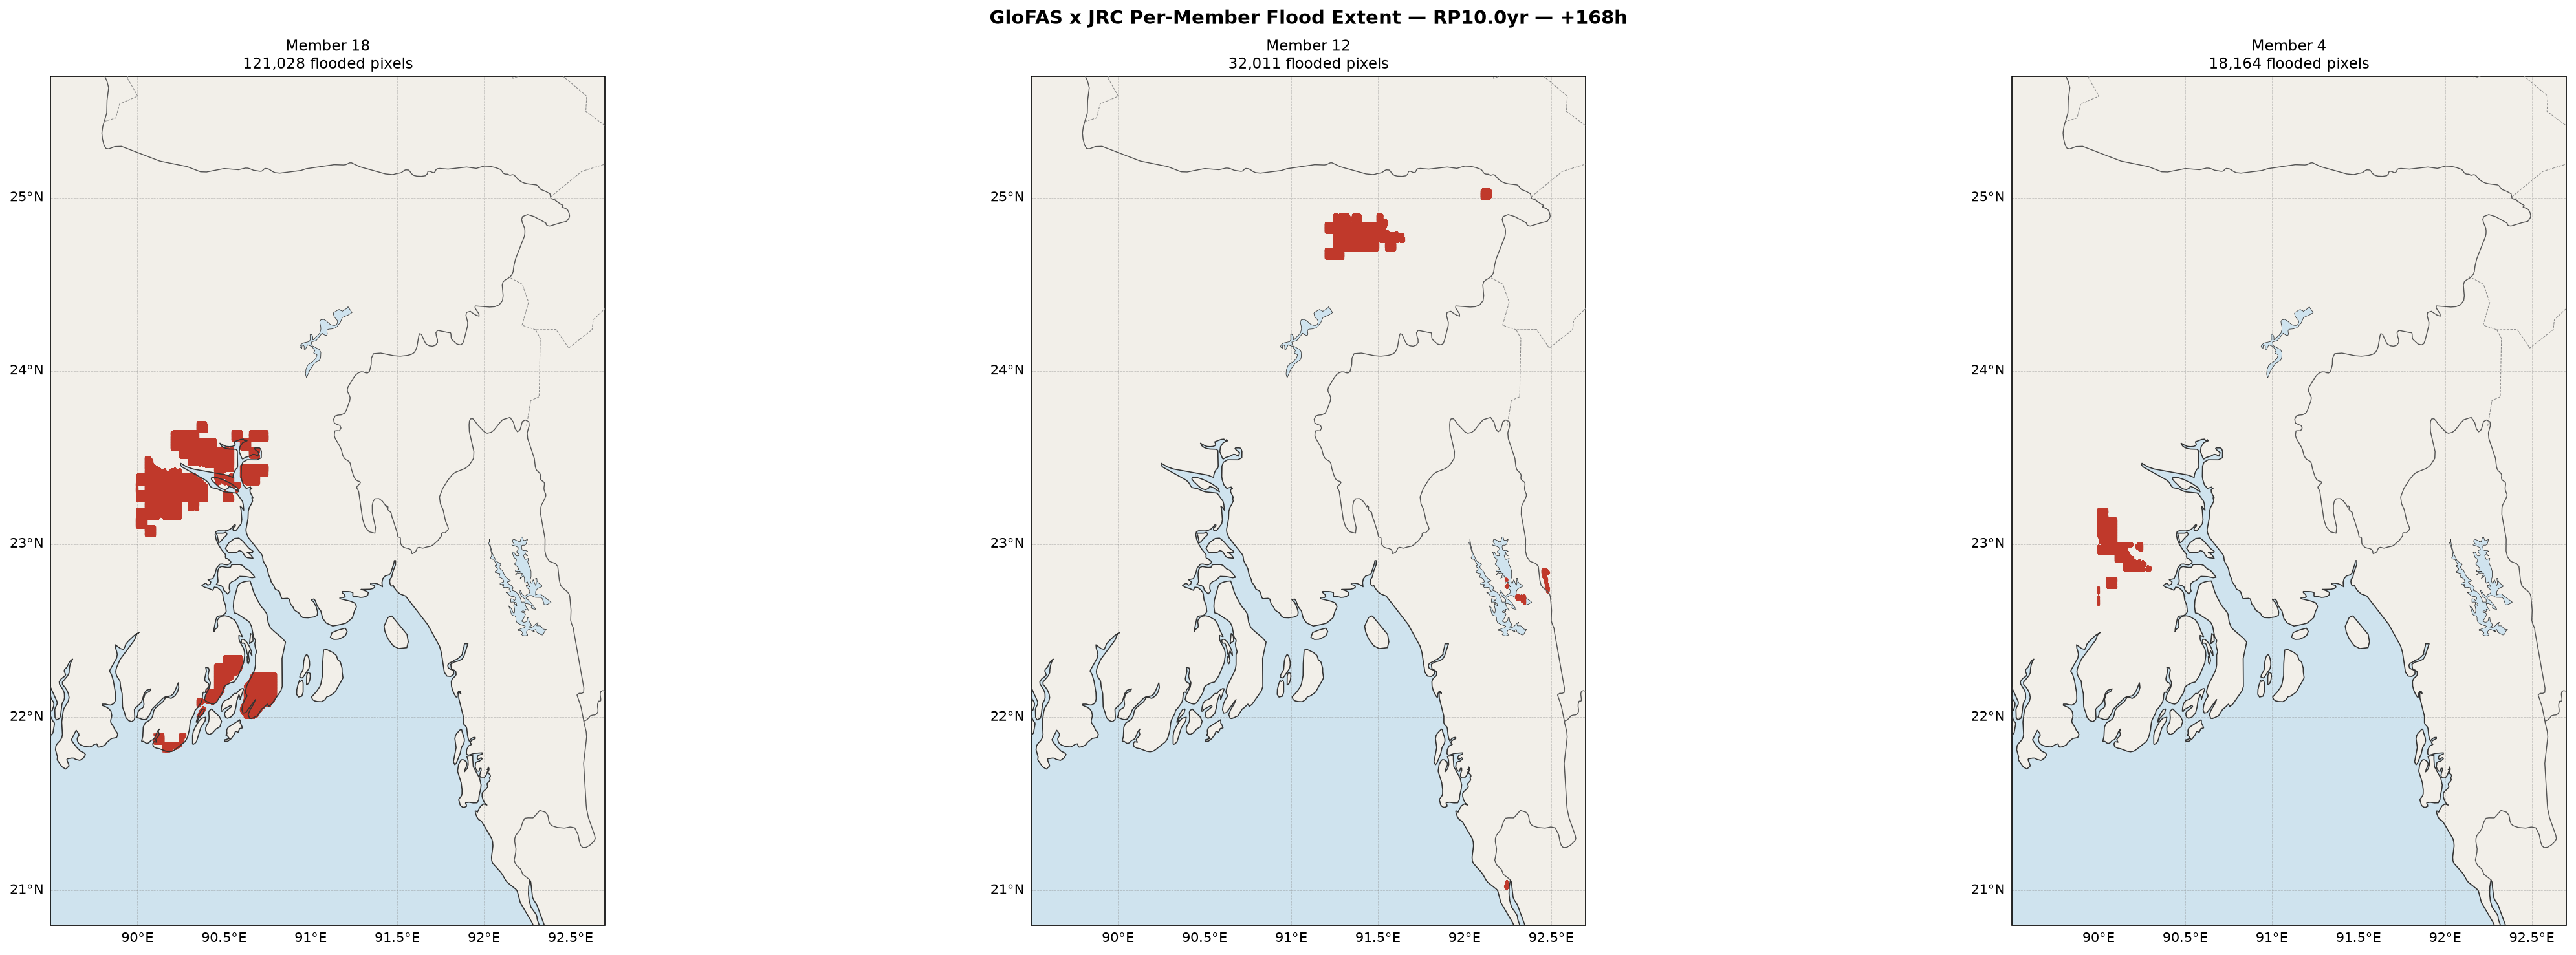

In [14]:
from visualization import show_glofas_member_extent

show_glofas_member_extent(zarr_path, jrc_local_dir=JRC_LOCAL_DIR, rp=EXTENT_RP,
                          step_h=EXTENT_STEP_H, members=MEMBERS_TO_COMPARE, bounds=BGD_BOUNDS)